# Geo-FNO Euler Comparison: Node Type vs Node Type + Pressure

This notebook loads one Euler sample and compares predictions from two trained Geo-FNO models:
1. velocity + node type
2. velocity + node type + pressure


Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]
sample=sample_000056 | node-type model MSE=2.925474e-03
sample=sample_000056 | node-type+pressure model MSE=2.358702e-03


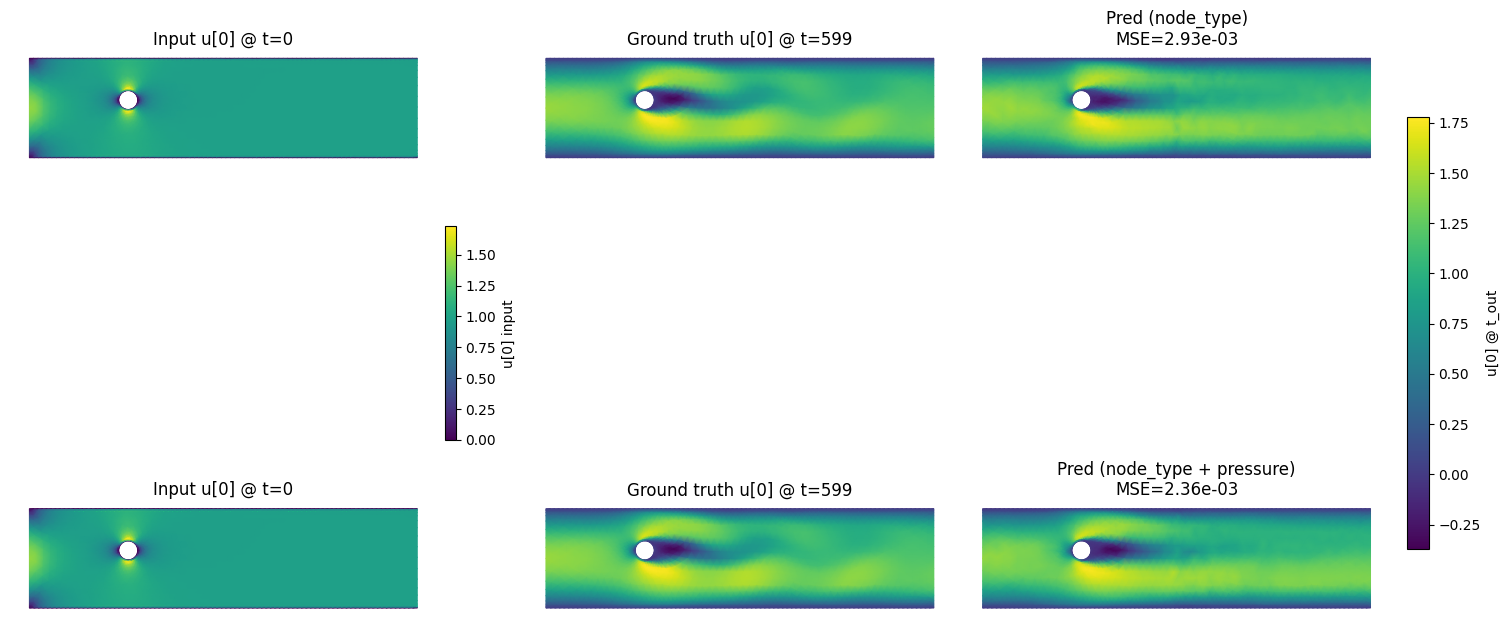

In [11]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

from geo_FNO_def import FNO2d, IPHI, get_global_L_from_h5

# ----------------------------
# Config
# ----------------------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"
sample_id = "sample_000056"
t_in = 0
t_out = 599
component = 0  # 0 -> u_x, 1 -> u_y

# Must match node_type mapping used in training
NODE_TYPE_VALUES = [0, 4, 5, 6]
NODE_TYPE_TO_IDX = {v: i for i, v in enumerate(NODE_TYPE_VALUES)}

# Model hyperparams (must match training)
modes = 20
width = 32
s1 = 80
s2 = 40

# Checkpoints
FNO_CKPT_NODE = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_fno.pt"
IPHI_CKPT_NODE = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_iphi.pt"

FNO_CKPT_NODE_PRESS = "/scratch/mnhagen/models/geofno/cylinder_vel_nodeType_pressure_t0_t-1_node_type_pressure_fno.pt"
IPHI_CKPT_NODE_PRESS = "/scratch/mnhagen/models/geofno/cylinder_vel_nodeType_pressure_t0_t-1_node_type_pressure_iphi.pt"

boundary_label = 6
band_frac = 0.06

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# ----------------------------
# Geometry utilities
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a*a + b_*b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)


def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r


def build_node_onehot(node_type: np.ndarray):
    feat = np.zeros((node_type.shape[0], len(NODE_TYPE_VALUES)), dtype=np.float32)
    for i, nt in enumerate(node_type.astype(np.int32)):
        feat[i, NODE_TYPE_TO_IDX[int(nt)]] = 1.0
    return feat


# ----------------------------
# Load one sample
# ----------------------------
with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]                 # (N,2)
    cells = g["cells"][:]             # (C,3)
    node_type = g["node_type"][:]     # (N,)
    vel = g["vel"][:]                 # (T,N,2)
    pressure = g["pressure"][:]       # (T,N)

u_vel_in = vel[t_in].astype(np.float32)              # (N,2)
u_out = vel[t_out].astype(np.float32)               # (N,2)
p_in = pressure[t_in].astype(np.float32)[:, None]    # (N,1)
node_feat = build_node_onehot(node_type)

u_in_node = np.concatenate([u_vel_in, node_feat], axis=-1)          # (N, 2+K)
u_in_node_press = np.concatenate([u_vel_in, node_feat, p_in], axis=-1)  # (N, 3+K)

xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r


# ----------------------------
# Load models
# ----------------------------
L_global, key_used = get_global_L_from_h5(H5_PATH)
print("Using L_global from", key_used, ":", L_global)

model_node = FNO2d(
    modes, modes, width,
    in_channels=2 + len(NODE_TYPE_VALUES),
    out_channels=2,
    is_mesh=False,
    s1=s1,
    s2=s2,
    L=L_global,
).to(device)
iphi_node = IPHI(width=32, device=str(device)).to(device)

model_node_press = FNO2d(
    modes, modes, width,
    in_channels=3 + len(NODE_TYPE_VALUES),
    out_channels=2,
    is_mesh=False,
    s1=s1,
    s2=s2,
    L=L_global,
).to(device)
iphi_node_press = IPHI(width=32, device=str(device)).to(device)

model_node.load_state_dict(torch.load(FNO_CKPT_NODE, map_location=device), strict=False)
iphi_node.load_state_dict(torch.load(IPHI_CKPT_NODE, map_location=device), strict=False)
model_node_press.load_state_dict(torch.load(FNO_CKPT_NODE_PRESS, map_location=device), strict=False)
iphi_node_press.load_state_dict(torch.load(IPHI_CKPT_NODE_PRESS, map_location=device), strict=False)

model_node.eval()
iphi_node.eval()
model_node_press.eval()
iphi_node_press.eval()


# ----------------------------
# Predict
# ----------------------------
pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)

u_in_node_t = torch.from_numpy(u_in_node).unsqueeze(0).to(device)
u_in_node_press_t = torch.from_numpy(u_in_node_press).unsqueeze(0).to(device)

with torch.no_grad():
    pred_node = model_node(u_in_node_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=iphi_node)[0].cpu().numpy().astype(np.float32)
    pred_node_press = model_node_press(u_in_node_press_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=iphi_node_press)[0].cpu().numpy().astype(np.float32)

mse_node = float(np.mean((pred_node - u_out) ** 2))
mse_node_press = float(np.mean((pred_node_press - u_out) ** 2))

print(f"sample={sample_id} | node-type model MSE={mse_node:.6e}")
print(f"sample={sample_id} | node-type+pressure model MSE={mse_node_press:.6e}")


# ----------------------------
# Plot: input / GT / prediction for both models
# ----------------------------
triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)

inp_field = u_vel_in[:, component]
gt_field = u_out[:, component]
pred_node_field = pred_node[:, component]
pred_node_press_field = pred_node_press[:, component]

common_min = float(min(gt_field.min(), pred_node_field.min(), pred_node_press_field.min()))
common_max = float(max(gt_field.max(), pred_node_field.max(), pred_node_press_field.max()))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

im00 = axes[0, 0].tripcolor(triang, inp_field, shading="gouraud")
axes[0, 0].set_title(f"Input u[{component}] @ t={t_in}")
axes[0, 0].set_aspect("equal")
axes[0, 0].axis("off")

im01 = axes[0, 1].tripcolor(triang, gt_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[0, 1].set_title(f"Ground truth u[{component}] @ t={t_out}")
axes[0, 1].set_aspect("equal")
axes[0, 1].axis("off")

im02 = axes[0, 2].tripcolor(triang, pred_node_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[0, 2].set_title(f"Pred (node_type)\nMSE={mse_node:.2e}")
axes[0, 2].set_aspect("equal")
axes[0, 2].axis("off")

im10 = axes[1, 0].tripcolor(triang, inp_field, shading="gouraud")
axes[1, 0].set_title(f"Input u[{component}] @ t={t_in}")
axes[1, 0].set_aspect("equal")
axes[1, 0].axis("off")

im11 = axes[1, 1].tripcolor(triang, gt_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[1, 1].set_title(f"Ground truth u[{component}] @ t={t_out}")
axes[1, 1].set_aspect("equal")
axes[1, 1].axis("off")

im12 = axes[1, 2].tripcolor(triang, pred_node_press_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[1, 2].set_title(f"Pred (node_type + pressure)\nMSE={mse_node_press:.2e}")
axes[1, 2].set_aspect("equal")
axes[1, 2].axis("off")

fig.colorbar(im00, ax=[axes[0, 0], axes[1, 0]], fraction=0.025, pad=0.02, label=f"u[{component}] input")
fig.colorbar(im01, ax=[axes[0, 1], axes[0, 2], axes[1, 1], axes[1, 2]], fraction=0.025, pad=0.02, label=f"u[{component}] @ t_out")

plt.show()

